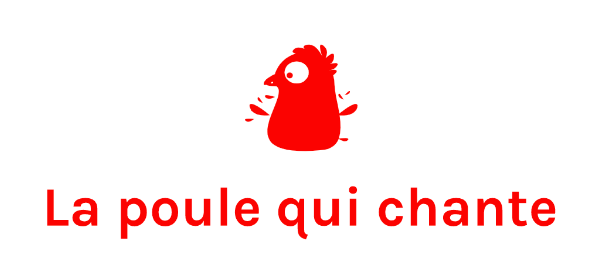

In [1]:
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns

from functions import *

col = findColor('Unknown.png')

pd.set_option('display.max_colwidth', None)

# 1 - Import des donnees fournies et verification du typage des colonnes

In [2]:
# 1.1 - list of countries with various grouping references - source : https://www.fao.org/faostat/en/#definitions
countries = pd.read_csv('../poule-qui-chante/databasebis/FAOSTAT_data_7-13-2025.csv', encoding='UTF8')

# 1.2 - population - source : https://www.fao.org/faostat/en/#data/OA
pop = pd.read_csv('../poule-qui-chante/databasebis/FAOSTAT_data_en_7-13-2025.csv', encoding='UTF8')

# 1.3 - GDP - source : https://www.fao.org/faostat/en/#data/MK
gdp = pd.read_csv('../poule-qui-chante/databasebis/FAOSTAT_data_en_7-13-2025-3.csv', encoding='UTF8')

# 1.4 - poultry products trade - source : https://www.fao.org/faostat/en/#data/TCL
trade = pd.read_csv('../poule-qui-chante/databasebis/FAOSTAT_data_en_7-13-2025-4.csv', encoding='UTF8')

# 1.5 - food stability, macro-economic and political stability indicators - source : https://www.fao.org/faostat/en/#data/FS
stability = pd.read_csv('../poule-qui-chante/databasebis/FAOSTAT_data_en_7-13-2025-5.csv', encoding='UTF8')

# 1.6 - sources & uses of domestic availability of poultry products - source : https://www.fao.org/faostat/en/#data/SCL
dispo = pd.read_csv('../poule-qui-chante/databasebis/FAOSTAT_data_en_7-13-2025-6.csv', encoding='UTF8')

# 1.7 - total availability of protein - source : https://www.fao.org/faostat/en/#data/SCL
protein = pd.read_csv('../poule-qui-chante/databasebis/FAOSTAT_data_en_5-9-2023_protein_tot_2020.csv', encoding='UTF8')

# 1.8 - animal protein consumption - # source : https://ourworldindata.org/grapher/animal-protein-vs-gdp
protein_anim = pd.read_csv('../poule-qui-chante/databasebis/OWID_animal-protein-vs-gdp_2020.csv', encoding='UTF8')

# 1.9 - deaths attributed to obesity - source : https://ourworldindata.org/obesity
obesity = pd.read_csv('../poule-qui-chante/databasebis/OWID_share-of-deaths-obesity_2019.csv', encoding='UTF8')

# 1.10 - trade as a percentage of GDP - source : https://ourworldindata.org/trade-and-globalization
open_economy = pd.read_csv('../poule-qui-chante/databasebis/OWID_trade-as-share-of-gdp_2020.csv', encoding='UTF8')

## 1.1 - Liste des pays

In [3]:
countries.head()

,Country Group Code,Country Group,Group M49 Code,Country Code,Country,M49 Code,ISO2 Code,ISO3 Code
0,5100,Africa,2.0,107,Côte d'Ivoire,384.0,CI,CIV
1,5100,Africa,2.0,114,Kenya,404.0,KE,KEN
2,5100,Africa,2.0,122,Lesotho,426.0,LS,LSO
3,5100,Africa,2.0,123,Liberia,430.0,LR,LBR
4,5100,Africa,2.0,124,Libya,434.0,LY,LBY


In [4]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2426 entries, 0 to 2425
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country Group Code  2426 non-null   int64  
 1   Country Group       2426 non-null   object 
 2   Group M49 Code      1893 non-null   float64
 3   Country Code        2426 non-null   int64  
 4   Country             2426 non-null   object 
 5   M49 Code            2326 non-null   float64
 6   ISO2 Code           2326 non-null   object 
 7   ISO3 Code           2334 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 151.8+ KB


In [5]:
countries['Country Group'].unique()

array(['Africa', 'All Donors', 'Americas', 'Annex I countries',
       'Antarctic Region', 'Asia', 'Australia and New Zealand',
       'Bilateral Donors', 'Bilateral Recipients', 'Caribbean',
       'Caucasus and Central Asia', 'Central America', 'Central Asia',
       'Central Asia and Southern Asia', 'Eastern Africa', 'Eastern Asia',
       'Eastern Asia (excluding Japan and China)',
       'Eastern Asia and South-eastern Asia', 'Eastern Europe', 'Europe',
       'Europe, Northern America, Australia and New Zealand',
       'European Union (27)', 'Land Locked Developing Countries (LLDCs)',
       'Latin America', 'Latin America and the Caribbean',
       'Least Developed Countries (LDCs)',
       'Low Income Food Deficit Countries (LIFDCs)', 'Melanesia',
       'Micronesia', 'Middle Africa', 'Multilateral Donors',
       'Net Food Importing Developing Countries (NFIDCs)',
       'Non-Annex I countries', 'North and Central America',
       'Northern Africa', 'Northern Africa (excludin

In [6]:
countries_list = countries.loc[countries["Country Group"] == 'World'][['Country','ISO3 Code', 'Country Group']]
countries_dup = countries_list[countries_list['Country'].duplicated()]
countries_dup

,Country,ISO3 Code,Country Group


In [7]:
ISO3_dup = countries_list[countries_list['ISO3 Code'].duplicated()]
ISO3_dup

,Country,ISO3 Code,Country Group


In [8]:

country = countries_list['Country'].unique()
country

array(['Armenia', 'Australia', 'India', 'Indonesia',
       'Iran (Islamic Republic of)', 'Iraq', 'Ireland', 'Israel', 'Italy',
       "Côte d'Ivoire", 'Kazakhstan', 'Jamaica', 'Austria', 'Japan',
       'Johnston Island', 'Jordan', 'Kyrgyzstan', 'Kenya', 'Cambodia',
       "Democratic People's Republic of Korea", 'Republic of Korea',
       'Kuwait', 'Latvia', 'Bahamas', "Lao People's Democratic Republic",
       'Lebanon', 'Lesotho', 'Liberia', 'Libya', 'Liechtenstein',
       'Lithuania', 'Marshall Islands', 'China, Macao SAR', 'Madagascar',
       'Bahrain', 'Malawi', 'Malaysia', 'Maldives', 'Mali', 'Malta',
       'Martinique', 'Mauritania', 'Mauritius', 'Mexico', 'Midway Island',
       'Barbados', 'Monaco', 'Mongolia', 'Montserrat', 'Morocco',
       'Mozambique', 'Micronesia (Federated States of)',
       'Republic of Moldova', 'Namibia', 'Nauru', 'Nepal',
       'Belgium-Luxembourg', 'Netherlands (Kingdom of the)',
       'Netherlands Antilles (former)', 'New Caledonia',
     

In [9]:
countries_out = ('Åland Islands','American Samoa','Anguilla','Antarctica','Aruba','Belgium-Luxembourg',
                 'Bonaire, Sint Eustatius and Saba','Bouvet Island','British Virgin Islands',
                 'Caribbean, unspecified (population)','Chagos Archipelago', 'Channel Islands','China','Christmas Island',
                 'Cocos (Keeling) Islands','Curaçao','Cyprus',"Democratic People's Republic of Korea",'Ethiopia PDR',
                 'Falkland Islands (Malvinas)','Faroe Islands','France','French Guiana','French Guyana','French Polynesia',
                 'French Southern Territories','Germany Fr','Germany Nl','Gibraltar','Greenland','Guadeloupe',
                 'Guam','Guernsey',
                 'Heard and McDonald Islands','Iran (Islamic Republic of)', 'Isle of Man','Jersey','Johnston Island','Martinique','Mayotte',
                 'Micronesia, unspecified','Midway Island','Montserrat','Myanmar','Netherlands Antilles (former)','New Caledonia',
                 'Norfolk Island','Northern America, unspecified (population)','Northern Europe, unspecified (population)',
                 'Northern Mariana Islands','Pacific Islands Trust Territory','Pitcairn','Polynesia, unspecified','Puerto Rico',
                 'Réunion', 'Russian Federation',
                 'Saint Barthélemy','Saint Helena, Ascension and Tristan da Cunha','Saint Martin (French part)',
                 'Saint Pierre and Miquelon','Saint-Martin (French part)','Serbia and Montenegro','Sint Maarten (Dutch part)',
                 'South America, unspecified','South Georgia and the South Sandwich Islands','Southern Europe, unspecified',
                 'Sudan (former)','Svalbard and Jan Mayen Islands','United States Minor Outlying Islands',
                 'United States Virgin Islands','USSR','Wake Island','Wallis and Futuna Islands','Western Africa, unspecified',
                 'Western Europe, unspecified (population)','Western Sahara','Yemen Ar Rp','Yemen Dem')

In [10]:
small_islands = countries.loc[countries['Country Group'] == 'Small Island Developing States']
small_islands_list = small_islands['Country'].unique().tolist()

In [11]:

countries_trim = countries_list.loc[(countries_list['Country'].isin(countries_out)) &
                                    (countries_list['Country'].isin(small_islands_list)) &
                                    (countries_list['ISO3 Code'].str.isalpha())].copy()
countries_trim.rename(columns={'Country': 'country', 'ISO3 Code':'iso3'}, inplace=True)

In [12]:
countries_dup2 = countries_trim[countries_trim['country'].duplicated()]
countries_dup2

,country,iso3,Country Group


In [13]:
isCandKey(countries_trim, 'country')

country est une clé candidate.


True

In [14]:
iso3_dup2 = countries_trim[countries_trim['iso3'].duplicated()]
iso3_dup2

,country,iso3,Country Group


In [15]:
isCandKey(countries_trim, 'iso3')

iso3 est une clé candidate.


True

In [16]:
countries_trim['country'] = countries_trim['country'].astype('category')
countries_trim['iso3'] = countries_trim['iso3'].astype('category')

In [17]:
print ("Il y a",countries_trim['country'].nunique(), "pays dans la liste.")
if (countries_trim.loc[countries_trim.duplicated(keep=False)].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 0 pays dans la liste.
Aucun doublon dans la table.


## 1.2 - Population

In [18]:
pop.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,OA,Annual population,4,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2020,2020,1000 No,39068.979,X,Figure from international organizations,NaN
1,OA,Annual population,4,Afghanistan,512,Total Population - Male,3010,Population - Est. & Proj.,2020,2020,1000 No,19725.450,X,Figure from international organizations,NaN
2,OA,Annual population,4,Afghanistan,513,Total Population - Female,3010,Population - Est. & Proj.,2020,2020,1000 No,19343.528,X,Figure from international organizations,NaN
3,OA,Annual population,4,Afghanistan,551,Rural population,3010,Population - Est. & Proj.,2020,2020,1000 No,28150.604,X,Figure from international organizations,NaN
4,OA,Annual population,4,Afghanistan,561,Urban population,3010,Population - Est. & Proj.,2020,2020,1000 No,9904.337,X,Figure from international organizations,NaN


In [19]:
pop['Element'].unique()

array(['Total Population - Both sexes', 'Total Population - Male',
       'Total Population - Female', 'Rural population',
       'Urban population'], dtype=object)

In [20]:
pop_tr = pop.loc[(pop['Element'] == 'Total Population - Both sexes')
                | (pop['Element'] == 'Urban population')][['Area','Element','Value']]
pop_tr.head()

,Area,Element,Value
0,Afghanistan,Total Population - Both sexes,39068.979
4,Afghanistan,Urban population,9904.337
5,Albania,Total Population - Both sexes,2871.954
9,Albania,Urban population,1827.362
10,Algeria,Total Population - Both sexes,44042.091


In [21]:
pop_tr['Value'] = pop_tr['Value'] * 1000
pop_tr.head()

,Area,Element,Value
0,Afghanistan,Total Population - Both sexes,39068979.0
4,Afghanistan,Urban population,9904337.0
5,Albania,Total Population - Both sexes,2871954.0
9,Albania,Urban population,1827362.0
10,Algeria,Total Population - Both sexes,44042091.0


In [22]:
pop_tr['Value'] = pop_tr['Value'].astype(int)
pop_tr['Area'] = pop_tr['Area'].astype(str)
pop_tr['Element'] = pop_tr['Element'].astype(str)
pop_tr.rename(columns={'Area': 'country_pop', 'Value':'millions_pop'}, inplace=True)
pop_tr.head()

,country_pop,Element,millions_pop
0,Afghanistan,Total Population - Both sexes,39068979
4,Afghanistan,Urban population,9904337
5,Albania,Total Population - Both sexes,2871954
9,Albania,Urban population,1827362
10,Algeria,Total Population - Both sexes,44042091


In [23]:
pop_trim = pop_tr.pivot(index='country_pop', columns='Element', values='millions_pop').reset_index()
pop_trim.rename(columns={'Total Population - Both sexes': 'total_pop', 'Urban population':'urban_pop'}, inplace=True)
pop_trim['country_pop'] = pop_trim['country_pop'].astype('category')
pop_trim.head()

Element,country_pop,total_pop,urban_pop
0,Afghanistan,39068979.0,9904337.0
1,Albania,2871954.0,1827362.0
2,Algeria,44042091.0,31950910.0
3,American Samoa,49761.0,48630.0
4,Andorra,77380.0,67857.0


In [24]:
print ("Il y a",pop_trim['country_pop'].nunique(), "pays dans le fichier de population.")
if (pop_trim.loc[pop_trim.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 236 pays dans le fichier de population.
Aucun doublon dans la table.


## 1.3 - GDP

In [25]:
gdp.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,MK,Macro Indicators,4,Afghanistan,6110,Value US$,22008,Gross Domestic Product,2020,2020,million USD,19983.008212,X,Figure from international organizations,NaN
1,MK,Macro Indicators,4,Afghanistan,6119,Value US$ per capita,22008,Gross Domestic Product,2020,2020,USD,511.480175,X,Figure from international organizations,NaN
2,MK,Macro Indicators,4,Afghanistan,6129,Annual growth US$,22008,Gross Domestic Product,2020,2020,%,3.152171,X,Figure from international organizations,NaN
3,MK,Macro Indicators,4,Afghanistan,6110,Value US$,22011,Gross National Income,2020,2020,million USD,20132.438423,X,Figure from international organizations,NaN
4,MK,Macro Indicators,4,Afghanistan,6119,Value US$ per capita,22011,Gross National Income,2020,2020,USD,515.304954,X,Figure from international organizations,NaN


In [26]:
gdp['Item'].unique()

array(['Gross Domestic Product', 'Gross National Income'], dtype=object)

In [27]:
gdp['Element'].unique()

array(['Value US$', 'Value US$ per capita', 'Annual growth US$'],
      dtype=object)

In [28]:
gdp_tr = gdp.loc[((gdp['Element'] == 'Value US$ per capita') & (gdp['Item'] == 'Gross Domestic Product'))
                |((gdp['Element'] == 'Annual growth US$') & (gdp['Item'] == 'Gross Domestic Product'))
                ][['Area','Element','Value']]
gdp_trim = gdp_tr.pivot(index='Area', columns='Element', values='Value').reset_index()

In [29]:
gdp_trim.rename(columns={'Area': 'country_gdp', 'Annual growth US$':'gdp_growth_%', 'Value US$ per capita':'gdp_per_cap_US$'
                        }, inplace=True)
gdp_trim['gdp_growth_%'] = gdp_trim['gdp_growth_%'].astype(float)
gdp_trim['gdp_per_cap_US$'] = gdp_trim['gdp_per_cap_US$'].astype(float)
gdp_trim['country_gdp'] = gdp_trim['country_gdp'].astype('category')

In [30]:
print("Il y a", gdp_trim['country_gdp'].nunique(),"pays dans le fichier PIB.")
if (gdp_trim.loc[gdp_trim.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 210 pays dans le fichier PIB.
Aucun doublon dans la table.


## 1.4 - Balance du commerce exterieur de la filiere poulet

In [31]:
trade.head(15)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,4,Afghanistan,5609,Import quantity,2151,Chickens,2020,2020,1000 An,49390,X,Figure from international organizations,Estimated data using trading partners database
1,TCL,Crops and livestock products,4,Afghanistan,5622,Import value,2151,Chickens,2020,2020,1000 USD,15341,X,Figure from international organizations,Estimated data using trading partners database
2,TCL,Crops and livestock products,8,Albania,5609,Import quantity,2151,Chickens,2020,2020,1000 An,644,A,Official figure,NaN
3,TCL,Crops and livestock products,8,Albania,5622,Import value,2151,Chickens,2020,2020,1000 USD,4591,A,Official figure,NaN
4,TCL,Crops and livestock products,12,Algeria,5609,Import quantity,2151,Chickens,2020,2020,1000 An,5248,X,Figure from international organizations,Estimated data using trading partners database
5,TCL,Crops and livestock products,12,Algeria,5622,Import value,2151,Chickens,2020,2020,1000 USD,26988,X,Figure from international organizations,Estimated data using trading partners database
6,TCL,Crops and livestock products,24,Angola,5609,Import quantity,2151,Chickens,2020,2020,1000 An,306,I,Imputed value,NaN
7,TCL,Crops and livestock products,24,Angola,5622,Import value,2151,Chickens,2020,2020,1000 USD,349,A,Official figure,NaN
8,TCL,Crops and livestock products,24,Angola,5909,Export quantity,2151,Chickens,2020,2020,1000 An,0,A,Official figure,NaN
9,TCL,Crops and livestock products,24,Angola,5922,Export value,2151,Chickens,2020,2020,1000 USD,0,A,Official figure,NaN


In [32]:
trade['Element'].unique()

array(['Import quantity', 'Import value', 'Export quantity',
       'Export value'], dtype=object)

In [33]:
trade_tr = trade.loc[(trade['Element'] == 'Import value') 
                     | ((trade['Element'] == 'Export value'))][['Area','Element','Item','Value']]

trade_tr['Value'] = trade_tr['Value'] * 1000

In [34]:
trade_tr.loc[(trade_tr['Element'] == 'Export value'), 'net_value'] = trade_tr['Value']*-1
trade_tr.loc[(trade_tr['Element'] == 'Import value'), 'net_value'] = trade_tr['Value']

In [35]:
trade_tr.groupby(['Area','Element'])['net_value'].sum().reset_index()

,Area,Element,net_value
0,Afghanistan,Import value,15341000.0
1,Albania,Import value,4591000.0
2,Algeria,Import value,26988000.0
3,Angola,Export value,0.0
4,Angola,Import value,349000.0
...,...,...,...
275,Yemen,Import value,9853000.0
276,Zambia,Export value,-5880000.0
277,Zambia,Import value,3380000.0
278,Zimbabwe,Export value,-1201000.0


In [36]:
trade_trim = trade_tr.groupby(['Area'])['net_value'].sum().reset_index()

In [37]:
trade_trim.rename(columns={'Area': 'country_trade', 'net_value':'net_imports_poultry_US$'}, inplace=True)
trade_trim['country_trade'] = trade_trim['country_trade'].astype('category')
trade_trim['net_imports_poultry_US$'] = trade_trim['net_imports_poultry_US$'].astype(float)

In [38]:
print("Il y a", trade_trim['country_trade'].nunique(), "pays dans le fichier des importations nettes de produits volaillers.")
if (trade_trim.loc[trade_trim.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 184 pays dans le fichier des importations nettes de produits volaillers.
Aucun doublon dans la table.


In [39]:
trade_trim

,country_trade,net_imports_poultry_US$
0,Afghanistan,15341000.0
1,Albania,4591000.0
2,Algeria,26988000.0
3,Angola,349000.0
4,Antigua and Barbuda,125000.0
...,...,...
179,Vanuatu,112000.0
180,Viet Nam,21808000.0
181,Yemen,9853000.0
182,Zambia,-2500000.0


## 1.5 - Indicateur de stabilite politique & structurelle

In [40]:
stability.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,FS,Suite of Food Security Indicators,4,Afghanistan,6123,Value,21013,Average protein supply (g/cap/day) (3-year average),20192021,2019-2021,g/cap/d,61.9,E,Estimated value,NaN
1,FS,Suite of Food Security Indicators,4,Afghanistan,6123,Value,21014,Average supply of protein of animal origin (g/cap/day) (3-year average),20192021,2019-2021,g/cap/d,10.6,E,Estimated value,NaN
2,FS,Suite of Food Security Indicators,4,Afghanistan,6126,Value,22013,"Gross domestic product per capita, PPP, (constant 2017 international $)",2020,2020,Int$/cap,2776.6,X,Figure from international organizations,NaN
3,FS,Suite of Food Security Indicators,4,Afghanistan,6125,Value,21032,Political stability and absence of violence/terrorism (index),2020,2020,NaN,-2.7,X,Figure from international organizations,NaN
4,FS,Suite of Food Security Indicators,8,Albania,6123,Value,21013,Average protein supply (g/cap/day) (3-year average),20192021,2019-2021,g/cap/d,116.5,E,Estimated value,NaN


In [41]:
stability['Item'].unique()

array(['Average protein supply (g/cap/day) (3-year average)',
       'Average supply of protein of animal origin (g/cap/day) (3-year average)',
       'Gross domestic product per capita, PPP, (constant 2017 international $)',
       'Political stability and absence of violence/terrorism (index)'],
      dtype=object)

In [42]:
stability_tr = stability.loc[(stability['Item'] == 'Political stability and absence of violence/terrorism (index)')
                            ][['Area','Item','Value']]
stability_trim = stability_tr.pivot(index='Area', columns='Item', values='Value').reset_index()
stability_trim.head()

Item,Area,Political stability and absence of violence/terrorism (index)
0,Afghanistan,-2.70
1,Albania,0.09
2,Algeria,-0.85
3,American Samoa,1.09
4,Andorra,1.59


In [43]:
stability_trim.rename(columns={'Area': 'country_stability',
                               'Political stability and absence of violence/terrorism (index)':'safety_stability_index'}
                      , inplace=True)
stability_trim['safety_stability_index'] = stability_trim['safety_stability_index'].astype(float)
stability_trim['country_stability'] = stability_trim['country_stability'].astype('category')

In [44]:
stability_trim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   country_stability       196 non-null    category
 1   safety_stability_index  196 non-null    float64 
dtypes: category(1), float64(1)
memory usage: 7.6 KB


In [45]:
print("Il y a", stability_trim['country_stability'].nunique(),"pays dans le fichier d'indicateur de stabilite politique et structurelle.")
if (stability_trim.loc[stability_trim.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 196 pays dans le fichier d'indicateur de stabilite politique et structurelle.
Aucun doublon dans la table.


## 1.6 - Disponibilite alimentaire totale des produits volaillers et des proteines de volaille

In [46]:
dispo.head(60)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,5610,Import quantity,21160.01,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",2020,2020,t,1.23,X,Figure from international organizations,Estimated data using trading partners database
1,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,5166,Residuals,21160.01,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",2020,2020,t,0.00,I,Imputed value,NaN
2,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,664,Food supply (kcal/capita/day),21160.01,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",2020,2020,kcal/cap/d,0.00,X,Figure from international organizations,Unofficial figure
3,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,665,Food supply quantity (g/capita/day),21160.01,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",2020,2020,g/cap/d,0.00,X,Figure from international organizations,Unofficial figure
4,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,674,Protein supply quantity (g/capita/day),21160.01,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",2020,2020,g/cap/d,0.00,X,Figure from international organizations,Unofficial figure
5,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,684,Fat supply quantity (g/capita/day),21160.01,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",2020,2020,g/cap/d,0.00,X,Figure from international organizations,Unofficial figure
6,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,261,Calories/Year,21160.01,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",2020,2020,million Kcal,1.56,X,Figure from international organizations,Unofficial figure
7,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,271,Proteins/Year,21160.01,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",2020,2020,t,0.21,X,Figure from international organizations,Unofficial figure
8,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,281,Fats/Year,21160.01,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",2020,2020,t,0.07,X,Figure from international organizations,Unofficial figure
9,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,5166,Residuals,21511.03,Fat of poultry,2020,2020,t,0.00,I,Imputed value,NaN


In [47]:
dispo['Element'].unique()

array(['Import quantity', 'Residuals', 'Food supply (kcal/capita/day)',
       'Food supply quantity (g/capita/day)',
       'Protein supply quantity (g/capita/day)',
       'Fat supply quantity (g/capita/day)', 'Calories/Year',
       'Proteins/Year', 'Fats/Year', 'Opening stocks', 'Production',
       'Stock Variation', 'Export quantity', 'Other uses (non-food)',
       'Processed', 'Loss', 'Feed'], dtype=object)

In [48]:
dispo['Item'].unique()

array(['Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen',
       'Fat of poultry', 'Meat of chickens, fresh or chilled',
       'Poultry fat, rendered', 'Poultry meat preparations'], dtype=object)

In [49]:
dispo_tr = dispo.loc[(dispo['Element'] == 'Food supply quantity (tonnes)')
                    | (dispo['Element'] == 'Protein supply quantity (g/capita/day)')][['Area','Item','Element','Value']]

In [50]:
dispo_tr

,Area,Item,Element,Value
4,Afghanistan,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",Protein supply quantity (g/capita/day),0.00
12,Afghanistan,Fat of poultry,Protein supply quantity (g/capita/day),0.00
25,Afghanistan,"Meat of chickens, fresh or chilled",Protein supply quantity (g/capita/day),0.73
33,Afghanistan,"Poultry fat, rendered",Protein supply quantity (g/capita/day),0.00
43,Afghanistan,Poultry meat preparations,Protein supply quantity (g/capita/day),0.00
...,...,...,...,...
7613,Zambia,Poultry meat preparations,Protein supply quantity (g/capita/day),0.00
7621,Zimbabwe,"Edible offals and liver of chickens and guinea fowl, fresh, chilled or frozen",Protein supply quantity (g/capita/day),0.00
7635,Zimbabwe,"Meat of chickens, fresh or chilled",Protein supply quantity (g/capita/day),3.25
7643,Zimbabwe,"Poultry fat, rendered",Protein supply quantity (g/capita/day),0.00


In [51]:
dispo_trim = dispo_tr.groupby(['Area','Element'])['Value'].sum().reset_index()

dispo_trim = dispo_trim.pivot(index='Area', columns='Element', values='Value').reset_index()
dispo_trim

Element,Area,Protein supply quantity (g/capita/day)
0,Afghanistan,0.73
1,Albania,6.56
2,Algeria,2.67
3,Angola,3.63
4,Antigua and Barbuda,29.44
...,...,...
184,Venezuela (Bolivarian Republic of),7.21
185,Viet Nam,6.58
186,Yemen,4.85
187,Zambia,1.50


In [52]:
dispo_trim.rename(columns={'Area': 'country_dispo',
                            'Protein supply quantity (g/capita/day)':'poultry_protein_g_cap_day'}, inplace=True)
dispo_trim['poultry_protein_g_cap_day'] = dispo_trim['poultry_protein_g_cap_day'].astype(float)
dispo_trim['country_dispo'] = dispo_trim['country_dispo'].astype('category')

In [53]:
print("Il y a",dispo_trim['country_dispo'].nunique(),"pays dans le fichier de disponibilite alimentaire.")
if (dispo_trim.loc[dispo_trim.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 189 pays dans le fichier de disponibilite alimentaire.
Aucun doublon dans la table.


## 1.7 - Disponibilite totale en proteines (animales et vegetales)

In [54]:
protein.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description
0,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,674,Protein supply quantity (g/capita/day),21422,"Almonds, shelled",2020,2020,g/capita/day,0.24,I,Imputed value
1,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,674,Protein supply quantity (g/capita/day),21529.03,Animal oils and fats n.e.c.,2020,2020,g/capita/day,0.00,I,Imputed value
2,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,674,Protein supply quantity (g/capita/day),34550,"Animal or vegetable fats and oils and their fractions, chemically modified, except those hydrogenated, inter-esterified, re-esterified or elaidinized; inedible mixtures or preparations of animal or vegetable fats or oils",2020,2020,g/capita/day,0.00,I,Imputed value
3,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,674,Protein supply quantity (g/capita/day),01654,"Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw",2020,2020,g/capita/day,0.07,I,Imputed value
4,SCL,Supply Utilization Accounts (2010-),4,Afghanistan,674,Protein supply quantity (g/capita/day),21435.01,Apple juice,2020,2020,g/capita/day,0.00,I,Imputed value


In [55]:
protein['Element'].unique()

array(['Protein supply quantity (g/capita/day)'], dtype=object)

In [56]:
protein_trim = protein.groupby('Area')['Value'].sum().reset_index()
protein_trim.head()

,Area,Value
0,Afghanistan,56.45
1,Albania,109.98
2,Algeria,88.32
3,Angola,43.94
4,Antigua and Barbuda,67.81


In [57]:
protein_trim.rename(columns={'Area': 'country_protein', 'Value':'total_protein_g_cap_day'}, inplace=True)
protein_trim['total_protein_g_cap_day'] = protein_trim['total_protein_g_cap_day'].astype(float)
protein_trim['country_protein'] = protein_trim['country_protein'].astype('category')
protein_trim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   country_protein          186 non-null    category
 1   total_protein_g_cap_day  186 non-null    float64 
dtypes: category(1), float64(1)
memory usage: 7.5 KB


In [58]:
print("Il y a", protein_trim['country_protein'].nunique(), "pays dans le fichier de disponibilite totale en proteines.")
if (protein_trim.loc[protein_trim.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 186 pays dans le fichier de disponibilite totale en proteines.
Aucun doublon dans la table.


## 1.8 - Consommation totale de proteines animales

In [59]:
protein_anim.head()

,Entity,Code,Year,Animal Products | 00002941 || Food available for consumption | 0674pc || grams of protein per day per capita,"GDP per capita, PPP (constant 2017 international $)",Population (historical estimates),Continent
0,Afghanistan,AFG,2020,10.448221,1970.560181,38972236,NaN
1,Albania,ALB,2020,59.114933,13191.952150,2866850,NaN
2,Algeria,DZA,2020,24.795826,10735.382810,43451668,NaN
3,American Samoa,ASM,2020,NaN,NaN,46216,NaN
4,Andorra,AND,2020,NaN,NaN,77723,NaN


In [60]:
protein_anim_trim = protein_anim[['Entity','Code',
                                  "Animal Products | 00002941 || Food available for consumption | 0674pc || grams of protein per day per capita"]].copy()
protein_anim_trim.head()

,Entity,Code,Animal Products | 00002941 || Food available for consumption | 0674pc || grams of protein per day per capita
0,Afghanistan,AFG,10.448221
1,Albania,ALB,59.114933
2,Algeria,DZA,24.795826
3,American Samoa,ASM,NaN
4,Andorra,AND,NaN


In [61]:
protein_anim_trim.rename(columns={'Entity': 'country_protein_anim',
                                 "Animal Products | 00002941 || Food available for consumption | 0674pc || grams of protein per day per capita":'animal_protein_g_cap_day',
                                 "Code" : 'iso_code'}, inplace=True)
protein_anim_trim['animal_protein_g_cap_day'] = protein_anim_trim['animal_protein_g_cap_day'].astype(float)
protein_anim_trim['country_protein_anim'] = protein_anim_trim['country_protein_anim'].astype('category')
protein_anim_trim['iso_code'] = protein_anim_trim['iso_code'].astype('category')

In [62]:
print("Il y a ", protein_anim_trim['country_protein_anim'].nunique(),
      "pays dans le fichier de consommation de proteines animales.")
if (protein_anim_trim.loc[protein_anim_trim.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a  236 pays dans le fichier de consommation de proteines animales.
Aucun doublon dans la table.


## 1.9 - Mortalite attribuee a l'obesite

In [63]:
obesity.head()

,Entity,Code,Year,Deaths - Cause: All causes - Risk: High body-mass index - Sex: Both - Age: Age-standardized (Percent)
0,Afghanistan,AFG,2019,12.34
1,Albania,ALB,2019,12.87
2,Algeria,DZA,2019,17.06
3,American Samoa,ASM,2019,22.38
4,Andorra,AND,2019,9.03


In [64]:
obesity_trim = obesity[['Entity','Code',
                        'Deaths - Cause: All causes - Risk: High body-mass index - Sex: Both - Age: Age-standardized (Percent)']].copy()

In [65]:
obesity_trim.rename(columns={'Entity': 'country_obesity',
                             "Deaths - Cause: All causes - Risk: High body-mass index - Sex: Both - Age: Age-standardized (Percent)":'obesity_deaths_%',
                             "Code" : 'iso_code'}, inplace=True)
obesity_trim['obesity_deaths_%'] = obesity_trim['obesity_deaths_%'].astype(float)
obesity_trim['country_obesity'] = obesity_trim['country_obesity'].astype('category')
obesity_trim['iso_code'] = obesity_trim['iso_code'].astype('category')

In [66]:
print("Il y a", obesity_trim['country_obesity'].nunique(), "pays dans le fichier de mortalite par obesite.")
if (obesity_trim.loc[obesity_trim.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 205 pays dans le fichier de mortalite par obesite.
Aucun doublon dans la table.


## 1.10 - Commerce exterieur en % du PIB

In [67]:
open_economy.head()

,Entity,Code,Year,Trade (% of GDP)
0,Albania,ALB,2020,60.969921
1,Algeria,DZA,2020,45.841991
2,American Samoa,ASM,2020,151.904083
3,Angola,AGO,2020,66.907478
4,Antigua and Barbuda,ATG,2020,91.525139


In [68]:
open_economy_trim = open_economy[['Entity','Code', 'Trade (% of GDP)']].copy()

In [69]:
open_economy_trim.rename(columns={'Entity': 'country_open_eco', "Trade (% of GDP)": 'trade_%_gdp',
                             "Code" : 'iso_code'}, inplace=True)
open_economy_trim['trade_%_gdp'] = open_economy_trim['trade_%_gdp'].astype(float)
open_economy_trim['country_open_eco'] = open_economy_trim['country_open_eco'].astype('category')
open_economy_trim['iso_code'] = open_economy_trim['iso_code'].astype('category')

In [70]:
print("Il y a", open_economy_trim['country_open_eco'].nunique(),"pays dans le fichier d'ouverture economique.")
if (open_economy_trim.loc[open_economy_trim.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 165 pays dans le fichier d'ouverture economique.
Aucun doublon dans la table.


## 1.11 - Jointure des tables & export du fichier .csv

In [71]:
data = countries_trim.merge(pop_trim,
                            how='left',
                            left_on='country',
                            right_on='country_pop').merge(gdp_trim,
                                                          how='left',
                                                          left_on='country',
                                                          right_on='country_gdp').merge(trade_trim,
                                                                                        how='left',
                                                                                        left_on='country',
                                                                                        right_on='country_trade').merge(stability_trim,
                                                                                                                        how='left',
                                                                                                                        left_on='country',
                                                                                                                        right_on='country_stability').merge(dispo_trim,
                                                                                                                                                            how='left',
                                                                                                                                                            left_on='country',
                                                                                                                                                            right_on='country_dispo').merge(protein_trim,
                                                                                                                                                                                            how='left',
                                                                                                                                                                                            left_on='country',
                                                                                                                                                                                            right_on='country_protein').merge(protein_anim_trim,
                                                                                                                                                                                                                              how='left',
                                                                                                                                                                                                                              left_on='iso3',
                                                                                                                                                                                                                              right_on='iso_code').merge(obesity_trim,
                                                                                                                                                                                                                                                         how='left',
                                                                                                                                                                                                                                                         left_on='iso3',
                                                                                                                                                                                                                                                         right_on='iso_code').merge(open_economy_trim,
                                                                                                                                                                                                                                                                                    how='left',
                                                                                                                                                                                                                                                                                    left_on='iso3',
                                                                                                                                                                                                                                                                                    right_on='iso_code').drop(columns=['country_pop', 'country_gdp', 'country_trade', 'country_stability', 'country_dispo', 'country_protein','country_protein_anim','country_open_eco','country_obesity','iso_code_x','iso_code_y','iso_code'])

In [72]:
data = data.loc[(~data['country'].isin(small_islands_list))                 
                     & (~data['poultry_protein_g_cap_day'].isna())
                     & (~data['trade_%_gdp'].isna())].copy()                   

In [73]:
data_holes = data.loc[data.isnull().any(axis=1)]
data_holes.head(data_holes.shape[0])

,country,iso3,Country Group,total_pop,urban_pop,gdp_growth_%,gdp_per_cap_US$,net_imports_poultry_US$,safety_stability_index,poultry_protein_g_cap_day,total_protein_g_cap_day,animal_protein_g_cap_day,obesity_deaths_%,trade_%_gdp


In [74]:
china_obesity = data.loc[(data['country'] == 'China, mainland'), 'obesity_deaths_%']
data.loc[(data['country'] == 'China, Hong Kong SAR'), 'obesity_deaths_%'] = china_obesity.values
data.loc[(data['country'] == 'China, Macao SAR'), 'obesity_deaths_%'] = china_obesity.values

In [75]:
hk_index = data.loc[(data['country'] == 'China, Hong Kong SAR'), 'safety_stability_index'] 
macao_index = data.loc[(data['country'] == 'China, Macao SAR'), 'safety_stability_index'] 
china_index = (hk_index.values + macao_index.values) / 2
data.loc[(data['country'] == 'China, mainland'), 'safety_stability_index'] = china_index

In [76]:
data = data.loc[(data['safety_stability_index'] > -2 )].copy() 
data = data.dropna()

In [77]:
data_holes = data.loc[data.isnull().any(axis=1)]
data_holes

,country,iso3,Country Group,total_pop,urban_pop,gdp_growth_%,gdp_per_cap_US$,net_imports_poultry_US$,safety_stability_index,poultry_protein_g_cap_day,total_protein_g_cap_day,animal_protein_g_cap_day,obesity_deaths_%,trade_%_gdp


In [78]:
print("Il y a", data['country'].nunique(),"pays dans le fichier final.")
if (data.loc[data.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a 0 pays dans le fichier final.
Aucun doublon dans la table.


In [79]:
data['urban_pop_%'] = data['urban_pop'] / data['total_pop']

In [80]:
data_final = data[['country', 
                   'urban_pop_%',
                   'gdp_growth_%', 'gdp_per_cap_US$','trade_%_gdp',
                   'net_imports_poultry_US$',
                   'safety_stability_index',
                   'total_protein_g_cap_day', 'animal_protein_g_cap_day',
                   'poultry_protein_g_cap_day',
                   'obesity_deaths_%', 
                   ]].copy()

In [81]:
data_final['country'] = data_final['country'].astype('category')
data_final['urban_pop_%'] = data_final['urban_pop_%'].astype(float)
data_final['gdp_growth_%'] = data_final['gdp_growth_%'].astype(float)
data_final['gdp_per_cap_US$'] = data_final['gdp_per_cap_US$'].astype(float)
data_final['trade_%_gdp'] = data_final['trade_%_gdp'].astype(float)

In [82]:
print("Il y a ", data_final['country'].nunique(),"pays dans le dataframe data_final.")
if (data_final.loc[data_final.duplicated()].shape[0]) != 0:
    print("Doublons dans la table.")
else:
    print ("Aucun doublon dans la table.")

Il y a  0 pays dans le dataframe data_final.
Aucun doublon dans la table.


#### Nous pouvons a present exporter le fichier pour proceder au clustering et a l'analyse en composantes principales.

In [83]:
data_final.to_csv('../poule-qui-chante/export/data_final_bis.csv', index=False, encoding='latin_1')

In [84]:
data_final

,country,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
